# 03 SP - Modelagem: Clustering de Setores Censitários (SP)

Mesmo pipeline do BA:
1. UMAP visualização 2D
2. HDBSCAN sobre features originais
3. Silhouette score
4. Heatmap de perfil dos clusters
5. Mapa geográfico

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path

OUTPUT_DIR = Path('../outputs')

df = pd.read_parquet(OUTPUT_DIR / 'setores_features_sp.parquet')

FEATURES = [
    'prop_domicilio_particular', 'prop_domicilio_coletivo',
    'prop_estab_agropecuario', 'prop_estab_ensino', 'prop_estab_saude',
    'prop_estab_outras', 'prop_construcao', 'prop_estab_religioso',
    'prop_finalidade_residencial', 'prop_finalidade_comercial', 'prop_finalidade_mista'
]

X = df[FEATURES].values
print(f'Setores: {len(df):,} | Features: {X.shape[1]}')

Setores: 98,902 | Features: 11


/home/wesleiferreira/Documentos/GitHub/trabalho-topicos-4/.venv/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


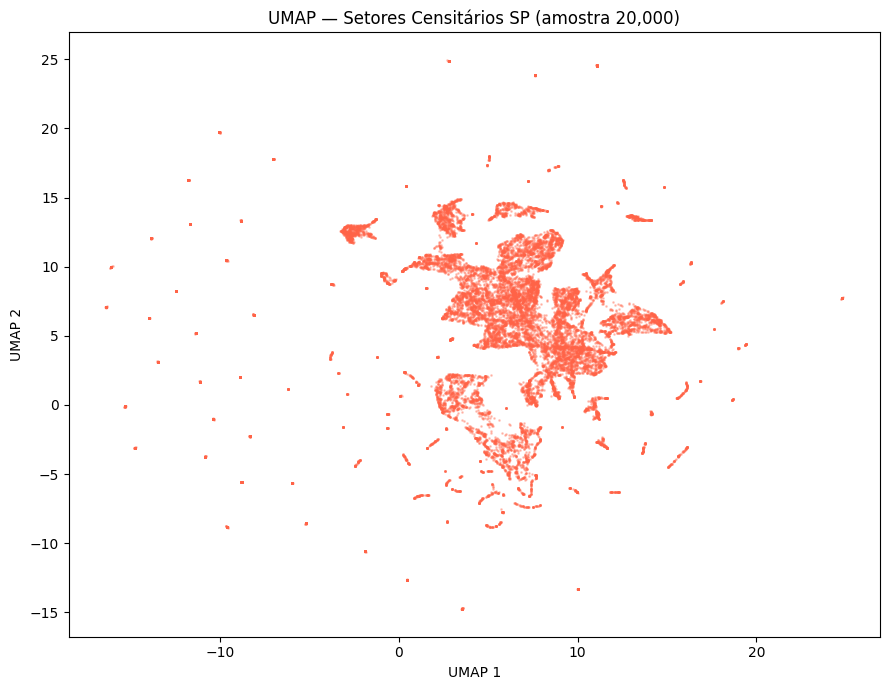

In [18]:
# UMAP — apenas visualização, roda sobre amostra de 20k para não travar
UMAP_SAMPLE = 20_000
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(df), size=min(UMAP_SAMPLE, len(df)), replace=False)
idx_sample.sort()

X_sample = X[idx_sample]

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    n_epochs=200, random_state=42)
embedding_sample = reducer.fit_transform(X_sample)

# guarda coordenadas UMAP só nos pontos amostrados
df['umap_x'] = np.nan
df['umap_y'] = np.nan
df.iloc[idx_sample, df.columns.get_loc('umap_x')] = embedding_sample[:, 0]
df.iloc[idx_sample, df.columns.get_loc('umap_y')] = embedding_sample[:, 1]

df_umap = df.iloc[idx_sample].copy()

plt.figure(figsize=(9, 7))
plt.scatter(df_umap['umap_x'], df_umap['umap_y'], s=1, alpha=0.3, c='tomato')
plt.title(f'UMAP — Setores Censitários SP (amostra {UMAP_SAMPLE:,})')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_umap_setores.png', dpi=150)
plt.show()

In [19]:
# HDBSCAN sobre features originais
# min_cluster_size escalado para o tamanho do dataset (~98k setores)
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=600,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
labels = clusterer.fit_predict(X)
df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = (labels == -1).sum()
print(f'Clusters encontrados : {n_clusters}')
print(f'Ruído (-1)           : {n_noise:,} ({n_noise/len(df)*100:.1f}%)')
print()
print(df['cluster'].value_counts().sort_index())

Clusters encontrados : 12
Ruído (-1)           : 56,630 (57.3%)

cluster
-1     56630
 0      1382
 1       688
 2      1738
 3      1947
 4     11210
 5      2831
 6      1369
 7      7864
 8      6821
 9      1142
 10     1834
 11     3446
Name: count, dtype: int64


In [20]:
# Silhouette no espaço original
mask = df['cluster'] != -1
if mask.sum() > 1 and df.loc[mask, 'cluster'].nunique() > 1:
    score = silhouette_score(X[mask], df.loc[mask, 'cluster'], sample_size=10000, random_state=42)
    print(f'Silhouette Score (SP): {score:.4f}')

Silhouette Score (SP): 0.1360


In [36]:
# Nomenclatura adaptativa: limiares baseados nos z-scores reais do dataset
NOMES_NRES = {
    'prop_estab_agropecuario':  'Rural / Agropecuário',
    'prop_estab_ensino':        'Educacional',
    'prop_estab_saude':         'Saúde',
    'prop_estab_outras':        'Comercial / Serviços',
    'prop_construcao':          'Em Construção',
    'prop_estab_religioso':     'Religioso',
    'prop_finalidade_comercial':'Comercial / Serviços',
    'prop_finalidade_mista':    'Uso Misto',
    'prop_domicilio_coletivo':  'Domicílio Coletivo',
}

perfil_z = (df[df['cluster'] != -1]
            .groupby('cluster')[FEATURES]
            .mean())

def nomear(row):
    # Uso Misto e Domicílio Coletivo: dominância clara
    if row['prop_finalidade_mista'] > 0.5:
        return 'Uso Misto'
    if row['prop_domicilio_coletivo'] > 0.5:
        return 'Domicílio Coletivo'

    # Feature não-residencial mais alta
    best_feat = max(NOMES_NRES, key=lambda f: row[f])
    best_z    = row[best_feat]
    dom_res   = row['prop_domicilio_particular']

    if best_z >= 0.2:
        prefixo = 'Residencial + ' if dom_res >= 0.2 else ''
        return f'{prefixo}{NOMES_NRES[best_feat]}'

    # Clusters puramente residenciais — diferencia por intensidade
    if dom_res >= 0.8:
        return 'Residencial Puro'
    if dom_res >= 0.4:
        return 'Residencial'
    return 'Residencial Típico'

cluster_nomes = perfil_z.apply(nomear, axis=1)

# sufixo numérico apenas em duplicatas
contagem = {}
for nome in cluster_nomes:
    contagem[nome] = contagem.get(nome, 0) + 1

contagem_uso = {}
nomes_finais = {}
for cid, nome in cluster_nomes.items():
    contagem_uso[nome] = contagem_uso.get(nome, 0) + 1
    nomes_finais[cid] = f'{nome} {contagem_uso[nome]}' if contagem[nome] > 1 else nome

df['cluster_nome'] = df['cluster'].map(lambda x: nomes_finais.get(x, 'Ruído') if x != -1 else 'Ruído')

tamanhos = df[df['cluster'] != -1]['cluster'].value_counts().sort_index()
print('Mapeamento de clusters:')
for cid, nome in sorted(nomes_finais.items()):
    print(f'  C{cid:>2} → {nome:<45} (n={tamanhos[cid]:,})')

Mapeamento de clusters:
  C 0 → Uso Misto                                     (n=1,382)
  C 1 → Residencial + Comercial / Serviços 1          (n=688)
  C 2 → Residencial + Comercial / Serviços 2          (n=1,738)
  C 3 → Residencial + Educacional 1                   (n=1,947)
  C 4 → Residencial + Religioso                       (n=11,210)
  C 5 → Residencial + Educacional 2                   (n=2,831)
  C 6 → Residencial + Saúde                           (n=1,369)
  C 7 → Residencial Puro 1                            (n=7,864)
  C 8 → Residencial 1                                 (n=6,821)
  C 9 → Residencial 2                                 (n=1,142)
  C10 → Residencial Puro 2                            (n=1,834)
  C11 → Residencial 3                                 (n=3,446)


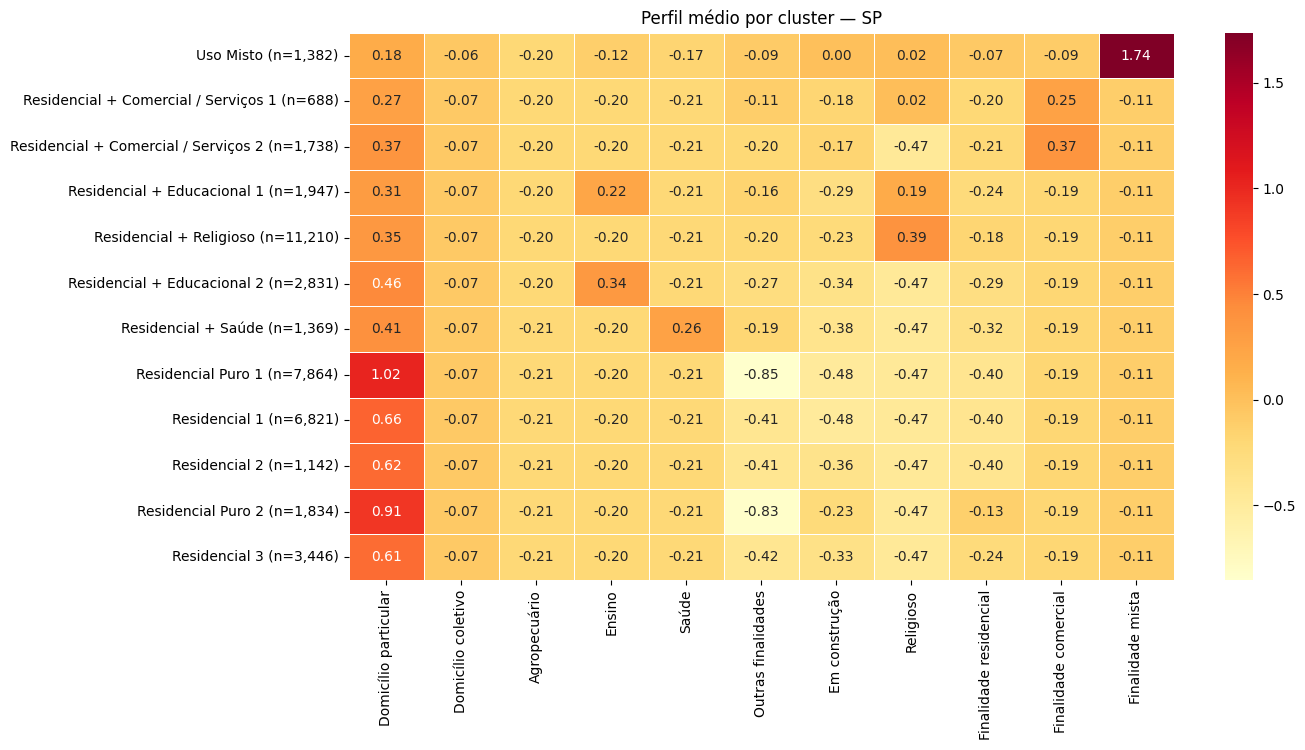

In [37]:
# Heatmap de perfil com nomes dos clusters
FEATURES_LABEL = {
    'prop_domicilio_particular':  'Domicílio particular',
    'prop_domicilio_coletivo':    'Domicílio coletivo',
    'prop_estab_agropecuario':    'Agropecuário',
    'prop_estab_ensino':          'Ensino',
    'prop_estab_saude':           'Saúde',
    'prop_estab_outras':          'Outras finalidades',
    'prop_construcao':            'Em construção',
    'prop_estab_religioso':       'Religioso',
    'prop_finalidade_residencial':'Finalidade residencial',
    'prop_finalidade_comercial':  'Finalidade comercial',
    'prop_finalidade_mista':      'Finalidade mista',
}

tamanhos = df[df['cluster'] != -1]['cluster'].value_counts().sort_index()

perfil = (df[df['cluster'] != -1]
          .groupby('cluster')[FEATURES]
          .mean()
          .rename(columns=FEATURES_LABEL))

perfil.index = [f"{nomes_finais[i]} (n={tamanhos[i]:,})" for i in perfil.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(perfil) * 0.55 + 1)))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil médio por cluster — SP')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_perfil_clusters_heatmap.png', dpi=150)
plt.show()

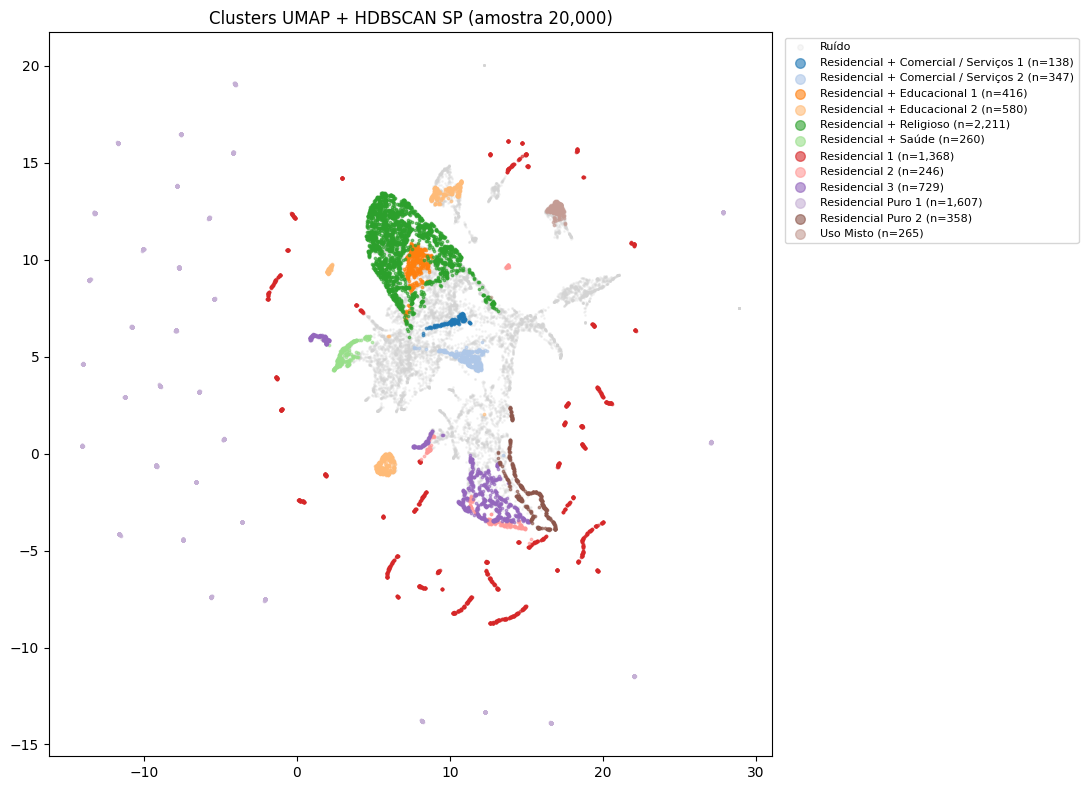

In [38]:
# UMAP colorido por cluster com nomes
df_umap = df.iloc[idx_sample].copy()

nomes_unicos = df_umap[df_umap['cluster'] != -1]['cluster_nome'].unique()
palette_nomes = {nome: plt.get_cmap('tab20')(i % 20) for i, nome in enumerate(sorted(nomes_unicos))}

fig, ax = plt.subplots(figsize=(11, 8))

noise_umap = df_umap[df_umap['cluster'] == -1]
ax.scatter(noise_umap['umap_x'], noise_umap['umap_y'], s=1, c='lightgray', alpha=0.2, label='Ruído')

for nome in sorted(nomes_unicos):
    sub = df_umap[df_umap['cluster_nome'] == nome]
    ax.scatter(sub['umap_x'], sub['umap_y'], s=3, alpha=0.6,
               color=palette_nomes[nome], label=f'{nome} (n={len(sub):,})')

ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title(f'Clusters UMAP + HDBSCAN SP (amostra {UMAP_SAMPLE:,})')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_clusters_umap.png', dpi=150)
plt.show()

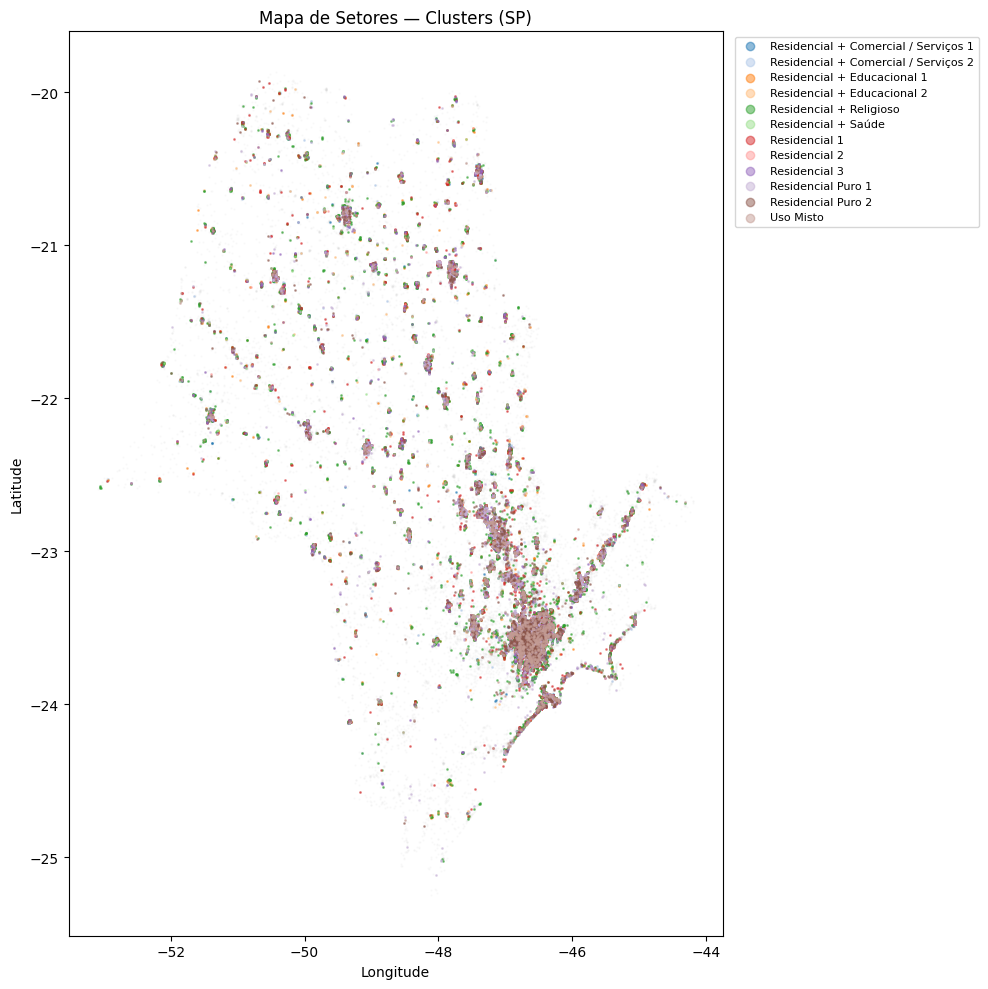

In [39]:
# Mapa geográfico com nomes
noise = df[df['cluster'] == -1]

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(noise['lon_centroide'], noise['lat_centroide'], s=0.3, c='lightgray', alpha=0.1)

for nome in sorted(nomes_unicos):
    sub = df[df['cluster_nome'] == nome]
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'], s=1, alpha=0.5,
               color=palette_nomes[nome], label=nome)

ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('Mapa de Setores — Clusters (SP)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/sp_clusters_mapa_geo.png', dpi=150)
plt.show()

In [40]:
df.to_parquet(OUTPUT_DIR / 'setores_clusterizados_sp.parquet', index=False)
print('Salvo: outputs/setores_clusterizados_sp.parquet')

Salvo: outputs/setores_clusterizados_sp.parquet
